In [15]:
import torch
import torch.nn.functional as F
from torch.nn import (
    Linear,
    ModuleList,
    BatchNorm1d,
    Sequential,
    ReLU
)
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

from torch_geometric.nn import (
    GCNConv,
    GINConv,
    SAGEConv,
    global_mean_pool,
    JumpingKnowledge
)
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)
from torch_geometric.utils import degree, to_networkx
import networkx as nx

import matplotlib.pyplot as plt
import copy


Using device: cpu


In [16]:
# ============================================================
# Chunk 1: Load ENZYMES Dataset
# ============================================================

import torch
from torch_geometric.datasets import TUDataset

dataset = TUDataset(
    root="data/TUDataset",
    name="ENZYMES"
)

print("Dataset:", dataset.name)
print("Number of graphs:", len(dataset))
print("Number of classes:", dataset.num_classes)
print("Node feature dimension:", dataset.num_node_features)

graph = dataset[0]

print("\nFirst graph:")
print(graph)

print("\nDetails:")
print("Nodes:", graph.num_nodes)
print("Edges:", graph.num_edges)
print("Feature shape:", graph.x.shape)
print("Label:", graph.y.item())

Dataset: ENZYMES
Number of graphs: 600
Number of classes: 6
Node feature dimension: 3

First graph:
Data(edge_index=[2, 168], x=[37, 3], y=[1])

Details:
Nodes: 37
Edges: 168
Feature shape: torch.Size([37, 3])
Label: 5


In [17]:
# ============================================================
# Chunk 2: Dataset Statistics
# ============================================================
num_nodes = []
num_edges = []
labels = []

for g in dataset:
    num_nodes.append(g.num_nodes)
    num_edges.append(g.num_edges)
    labels.append(g.y.item())

print("Average nodes:", np.mean(num_nodes))
print("Average edges:", np.mean(num_edges))
print("Min nodes:", np.min(num_nodes))
print("Max nodes:", np.max(num_nodes))

label_counts = pd.Series(labels).value_counts().sort_index()

print("\nClass Distribution")
print(label_counts)

Average nodes: 32.63333333333333
Average edges: 124.27333333333333
Min nodes: 2
Max nodes: 126

Class Distribution
0    100
1    100
2    100
3    100
4    100
5    100
Name: count, dtype: int64


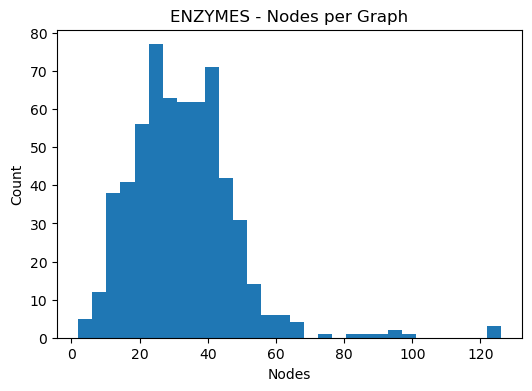

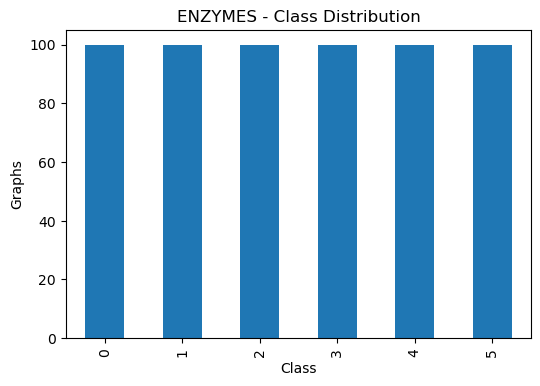

In [18]:
# ============================================================
# Chunk 3: Visualization
# ============================================================

plt.figure(figsize=(6,4))
plt.hist(num_nodes, bins=30)
plt.title("ENZYMES - Nodes per Graph")
plt.xlabel("Nodes")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(6,4))
label_counts.plot(kind="bar")
plt.title("ENZYMES - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Graphs")
plt.show()

In [19]:
def add_node_initialization(dataset, init_type, random_dim=18, seed=42):
    torch.manual_seed(seed)
    new_dataset = []

    for graph in dataset:
        g = copy.deepcopy(graph)
        num_nodes = g.num_nodes

        if init_type == "original":
            g.x = g.x.float()

        elif init_type == "constant":
            g.x = torch.ones((num_nodes, 1), dtype=torch.float)

        elif init_type == "random":
            g.x = torch.randn((num_nodes, random_dim), dtype=torch.float)

        elif init_type == "degree":
            deg = degree(g.edge_index[0], num_nodes=num_nodes)
            g.x = deg.view(-1, 1).float()

        elif init_type == "degree_clustering":
            deg = degree(g.edge_index[0], num_nodes=num_nodes).view(-1, 1)

            nx_graph = to_networkx(g, to_undirected=True)
            clustering_dict = nx.clustering(nx_graph)

            clustering = torch.tensor(
                [clustering_dict[i] for i in range(num_nodes)],
                dtype=torch.float
            ).view(-1, 1)

            g.x = torch.cat([deg, clustering], dim=1).float()

        else:
            raise ValueError("Unknown init_type")

        new_dataset.append(g)

    return new_dataset


def add_feature_masking(dataset, mask_ratio, seed=42):
    torch.manual_seed(seed)
    new_dataset = []

    for graph in dataset:
        g = copy.deepcopy(graph)
        x = g.x.float().clone()

        if mask_ratio == 1.0:
            g.x = torch.zeros_like(x)
        else:
            mask = torch.rand_like(x) > mask_ratio
            g.x = x * mask.float()

        new_dataset.append(g)

    return new_dataset

In [20]:

init_types = [
    "original",
    "constant",
    "random",
    "degree",
    "degree_clustering"
]

for init in init_types:
    temp_dataset = add_node_initialization(dataset, init)
    print(init)
    print("Feature shape:", temp_dataset[0].x.shape)
    print(temp_dataset[0].x[:5])
    print("-" * 50)

original
Feature shape: torch.Size([37, 3])
tensor([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]])
--------------------------------------------------
constant
Feature shape: torch.Size([37, 1])
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])
--------------------------------------------------
random
Feature shape: torch.Size([37, 18])
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047,
         -0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,  0.7624,
          1.6423, -0.1596],
        [-0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806,  1.2791,  1.2964,
          0.6105,  1.3347, -0.2316,  0.0418, -0.2516,  0.8599, -1.3847, -0.8712,
         -0.2234,  1.7174],
        [ 0.3189, -0.4245,  0.3057, -0.7746, -1.5576,  0.9956, -0.8798, -0.6011,
         -1.2742,  2.1228, -1.2347, -0.4879, -0.9138, -0.6581,  0.0780,  0.5258,
         -0.4880,  1.1914],
        [-0.814

In [21]:
class BetterGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = ModuleList()
        self.bns = ModuleList()

        self.convs.append(GCNConv(input_dim, hidden_dim))
        self.bns.append(BatchNorm1d(hidden_dim))

        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.bns.append(BatchNorm1d(hidden_dim))

        self.jk = JumpingKnowledge(mode="cat")
        self.lin1 = Linear(hidden_dim * num_layers, hidden_dim)
        self.lin2 = Linear(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        layer_outputs = []

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x.float(), edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            layer_outputs.append(x)

        x = self.jk(layer_outputs)
        x = global_mean_pool(x, batch)

        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x


class BetterGIN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = ModuleList()
        self.bns = ModuleList()

        for layer in range(num_layers):
            in_dim = input_dim if layer == 0 else hidden_dim

            mlp = Sequential(
                Linear(in_dim, hidden_dim),
                BatchNorm1d(hidden_dim),
                ReLU(),
                Linear(hidden_dim, hidden_dim),
                ReLU()
            )

            self.convs.append(GINConv(mlp))
            self.bns.append(BatchNorm1d(hidden_dim))

        self.jk = JumpingKnowledge(mode="cat")
        self.lin1 = Linear(hidden_dim * num_layers, hidden_dim)
        self.lin2 = Linear(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        layer_outputs = []

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x.float(), edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            layer_outputs.append(x)

        x = self.jk(layer_outputs)
        x = global_mean_pool(x, batch)

        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x


class BetterGraphSAGE(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = ModuleList()
        self.bns = ModuleList()

        self.convs.append(SAGEConv(input_dim, hidden_dim))
        self.bns.append(BatchNorm1d(hidden_dim))

        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
            self.bns.append(BatchNorm1d(hidden_dim))

        self.jk = JumpingKnowledge(mode="cat")
        self.lin1 = Linear(hidden_dim * num_layers, hidden_dim)
        self.lin2 = Linear(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        layer_outputs = []

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x.float(), edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            layer_outputs.append(x)

        x = self.jk(layer_outputs)
        x = global_mean_pool(x, batch)

        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x

In [22]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            out = model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1)

            correct += int((pred == batch.y).sum())
            total += batch.num_graphs

    return correct / total

In [23]:
def run_experiment_on_dataset(
    input_dataset,
    model_class,
    model_name,
    setting_name,
    seed=42,
    epochs=200,
    hidden_dim=64,
    num_layers=3,
    dropout=0.5,
    batch_size=32
):
    set_seed(seed)

    labels = [g.y.item() for g in input_dataset]
    indices = list(range(len(input_dataset)))

    train_idx, temp_idx = train_test_split(
        indices,
        test_size=0.30,
        random_state=seed,
        stratify=labels
    )

    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.50,
        random_state=seed,
        stratify=[labels[i] for i in temp_idx]
    )

    train_loader = DataLoader(
        [input_dataset[i] for i in train_idx],
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        [input_dataset[i] for i in val_idx],
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        [input_dataset[i] for i in test_idx],
        batch_size=batch_size,
        shuffle=False
    )

    input_dim = input_dataset[0].x.shape[1]

    model = model_class(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_classes=dataset.num_classes,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,
        weight_decay=5e-4
    )

    best_val_acc = 0
    best_test_acc = 0

    for epoch in range(1, epochs + 1):
        train_one_epoch(model, train_loader, optimizer, device)
        val_acc = evaluate(model, val_loader, device)
        test_acc = evaluate(model, test_loader, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc

    return {
        "model": model_name,
        "setting": setting_name,
        "seed": seed,
        "layers": num_layers,
        "best_val_acc": best_val_acc,
        "test_acc": best_test_acc
    }


def run_initialization_experiment(
    model_class,
    model_name,
    init_type,
    seed=42,
    epochs=200,
    hidden_dim=64,
    num_layers=3
):
    temp_dataset = add_node_initialization(dataset, init_type, seed=seed)

    return run_experiment_on_dataset(
        input_dataset=temp_dataset,
        model_class=model_class,
        model_name=model_name,
        setting_name=init_type,
        seed=seed,
        epochs=epochs,
        hidden_dim=hidden_dim,
        num_layers=num_layers
    )

In [24]:
models = [
    (BetterGCN, "GCN"),
    (BetterGIN, "GIN"),
    (BetterGraphSAGE, "GraphSAGE")
]

initializations = [
    "original",
    "constant",
    "random",
    "degree",
    "degree_clustering"
]

init_results = []

for model_class, model_name in models:
    for init_type in initializations:

        print(f"Running {model_name} + {init_type}")

        result = run_initialization_experiment(
            model_class=model_class,
            model_name=model_name,
            init_type=init_type,
            seed=42,
            epochs=200,
            hidden_dim=64,
            num_layers=3
        )

        init_results.append(result)
        print(result)
        print("-" * 50)

init_df = pd.DataFrame(init_results)
init_df

Running GCN + original
{'model': 'GCN', 'setting': 'original', 'seed': 42, 'layers': 3, 'best_val_acc': 0.37777777777777777, 'test_acc': 0.37777777777777777}
--------------------------------------------------
Running GCN + constant
{'model': 'GCN', 'setting': 'constant', 'seed': 42, 'layers': 3, 'best_val_acc': 0.2777777777777778, 'test_acc': 0.2}
--------------------------------------------------
Running GCN + random
{'model': 'GCN', 'setting': 'random', 'seed': 42, 'layers': 3, 'best_val_acc': 0.26666666666666666, 'test_acc': 0.2222222222222222}
--------------------------------------------------
Running GCN + degree
{'model': 'GCN', 'setting': 'degree', 'seed': 42, 'layers': 3, 'best_val_acc': 0.24444444444444444, 'test_acc': 0.18888888888888888}
--------------------------------------------------
Running GCN + degree_clustering
{'model': 'GCN', 'setting': 'degree_clustering', 'seed': 42, 'layers': 3, 'best_val_acc': 0.28888888888888886, 'test_acc': 0.2777777777777778}
---------------

,model,setting,seed,layers,best_val_acc,test_acc
0,GCN,original,42,3,0.377778,0.377778
1,GCN,constant,42,3,0.277778,0.200000
2,GCN,random,42,3,0.266667,0.222222
3,GCN,degree,42,3,0.244444,0.188889
4,GCN,degree_clustering,42,3,0.288889,0.277778
5,GIN,original,42,3,0.433333,0.400000
6,GIN,constant,42,3,0.266667,0.188889
7,GIN,random,42,3,0.288889,0.177778
8,GIN,degree,42,3,0.255556,0.222222
9,GIN,degree_clustering,42,3,0.311111,0.233333


In [25]:
mask_ratios = [0.00, 0.25, 0.50, 0.75, 1.00]

masking_results = []

for model_class, model_name in models:
    for mask_ratio in mask_ratios:

        print(f"Running {model_name} with {int(mask_ratio * 100)}% masking")

        if mask_ratio == 0.00:
            masked_dataset = add_node_initialization(dataset, "original")
        else:
            masked_dataset = add_feature_masking(dataset, mask_ratio=mask_ratio, seed=42)

        result = run_experiment_on_dataset(
            input_dataset=masked_dataset,
            model_class=model_class,
            model_name=model_name,
            setting_name=f"{int(mask_ratio * 100)}% masking",
            seed=42,
            epochs=200,
            hidden_dim=64,
            num_layers=3
        )

        masking_results.append(result)
        print(result)
        print("-" * 50)

masking_df = pd.DataFrame(masking_results)
masking_df

Running GCN with 0% masking
{'model': 'GCN', 'setting': '0% masking', 'seed': 42, 'layers': 3, 'best_val_acc': 0.37777777777777777, 'test_acc': 0.37777777777777777}
--------------------------------------------------
Running GCN with 25% masking
{'model': 'GCN', 'setting': '25% masking', 'seed': 42, 'layers': 3, 'best_val_acc': 0.28888888888888886, 'test_acc': 0.25555555555555554}
--------------------------------------------------
Running GCN with 50% masking
{'model': 'GCN', 'setting': '50% masking', 'seed': 42, 'layers': 3, 'best_val_acc': 0.32222222222222224, 'test_acc': 0.3111111111111111}
--------------------------------------------------
Running GCN with 75% masking
{'model': 'GCN', 'setting': '75% masking', 'seed': 42, 'layers': 3, 'best_val_acc': 0.2777777777777778, 'test_acc': 0.13333333333333333}
--------------------------------------------------
Running GCN with 100% masking
{'model': 'GCN', 'setting': '100% masking', 'seed': 42, 'layers': 3, 'best_val_acc': 0.166666666666666

,model,setting,seed,layers,best_val_acc,test_acc
0,GCN,0% masking,42,3,0.377778,0.377778
1,GCN,25% masking,42,3,0.288889,0.255556
2,GCN,50% masking,42,3,0.322222,0.311111
3,GCN,75% masking,42,3,0.277778,0.133333
4,GCN,100% masking,42,3,0.166667,0.166667
5,GIN,0% masking,42,3,0.433333,0.400000
6,GIN,25% masking,42,3,0.388889,0.233333
7,GIN,50% masking,42,3,0.333333,0.211111
8,GIN,75% masking,42,3,0.255556,0.100000
9,GIN,100% masking,42,3,0.222222,0.155556


In [26]:
layer_values = [2, 3, 4, 5]

oversmoothing_results = []

original_dataset = add_node_initialization(dataset, "original")

for model_class, model_name in models:
    for num_layers in layer_values:

        print(f"Running {model_name} with {num_layers} layers")

        result = run_experiment_on_dataset(
            input_dataset=original_dataset,
            model_class=model_class,
            model_name=model_name,
            setting_name="original_features",
            seed=42,
            epochs=200,
            hidden_dim=64,
            num_layers=num_layers
        )

        oversmoothing_results.append(result)
        print(result)
        print("-" * 50)

oversmoothing_df = pd.DataFrame(oversmoothing_results)
oversmoothing_df

Running GCN with 2 layers
{'model': 'GCN', 'setting': 'original_features', 'seed': 42, 'layers': 2, 'best_val_acc': 0.3888888888888889, 'test_acc': 0.32222222222222224}
--------------------------------------------------
Running GCN with 3 layers
{'model': 'GCN', 'setting': 'original_features', 'seed': 42, 'layers': 3, 'best_val_acc': 0.37777777777777777, 'test_acc': 0.37777777777777777}
--------------------------------------------------
Running GCN with 4 layers
{'model': 'GCN', 'setting': 'original_features', 'seed': 42, 'layers': 4, 'best_val_acc': 0.3333333333333333, 'test_acc': 0.35555555555555557}
--------------------------------------------------
Running GCN with 5 layers
{'model': 'GCN', 'setting': 'original_features', 'seed': 42, 'layers': 5, 'best_val_acc': 0.3888888888888889, 'test_acc': 0.4}
--------------------------------------------------
Running GIN with 2 layers
{'model': 'GIN', 'setting': 'original_features', 'seed': 42, 'layers': 2, 'best_val_acc': 0.3888888888888889,

,model,setting,seed,layers,best_val_acc,test_acc
0,GCN,original_features,42,2,0.388889,0.322222
1,GCN,original_features,42,3,0.377778,0.377778
2,GCN,original_features,42,4,0.333333,0.355556
3,GCN,original_features,42,5,0.388889,0.400000
4,GIN,original_features,42,2,0.388889,0.344444
5,GIN,original_features,42,3,0.433333,0.400000
6,GIN,original_features,42,4,0.388889,0.400000
7,GIN,original_features,42,5,0.400000,0.311111
8,GraphSAGE,original_features,42,2,0.344444,0.388889
9,GraphSAGE,original_features,42,3,0.311111,0.288889


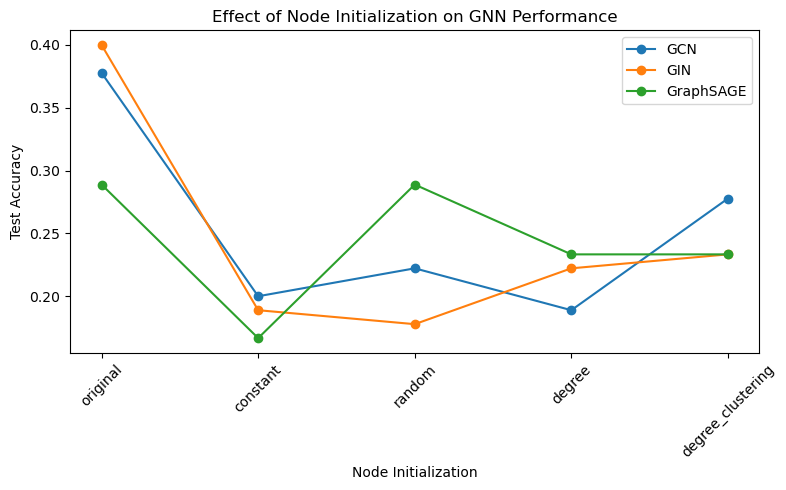

In [27]:
plt.figure(figsize=(8, 5))

for model_name in init_df["model"].unique():
    temp = init_df[init_df["model"] == model_name]
    plt.plot(temp["setting"], temp["test_acc"], marker="o", label=model_name)

plt.xlabel("Node Initialization")
plt.ylabel("Test Accuracy")
plt.title("Effect of Node Initialization on GNN Performance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

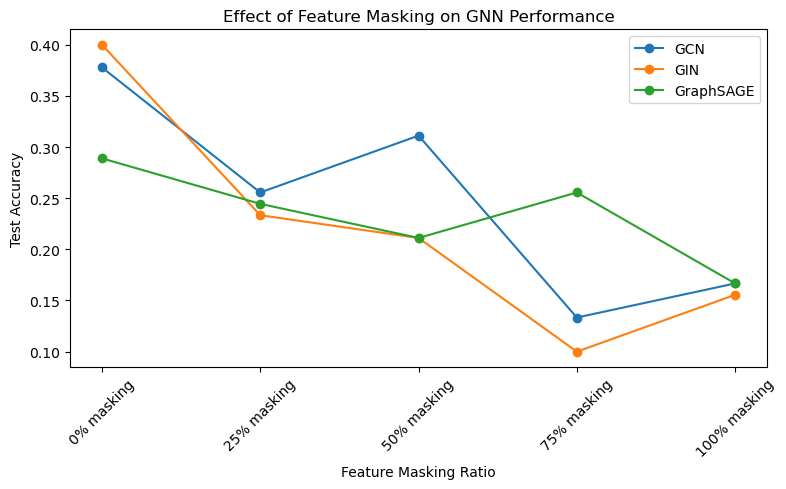

In [28]:
plt.figure(figsize=(8, 5))

for model_name in masking_df["model"].unique():
    temp = masking_df[masking_df["model"] == model_name]
    plt.plot(temp["setting"], temp["test_acc"], marker="o", label=model_name)

plt.xlabel("Feature Masking Ratio")
plt.ylabel("Test Accuracy")
plt.title("Effect of Feature Masking on GNN Performance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

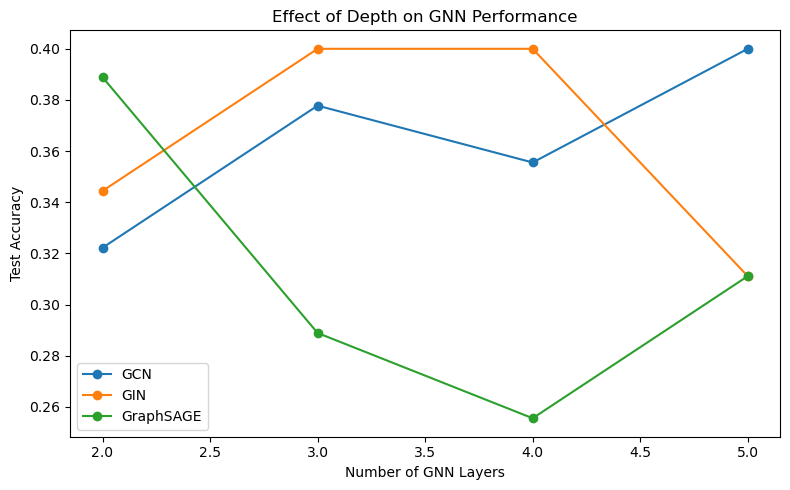

In [29]:
plt.figure(figsize=(8, 5))

for model_name in oversmoothing_df["model"].unique():
    temp = oversmoothing_df[oversmoothing_df["model"] == model_name]
    plt.plot(temp["layers"], temp["test_acc"], marker="o", label=model_name)

plt.xlabel("Number of GNN Layers")
plt.ylabel("Test Accuracy")
plt.title("Effect of Depth on GNN Performance")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
print("\n=== Node Initialization Results ===")
display(init_df.sort_values(["model", "test_acc"], ascending=[True, False]))

print("\n=== Feature Masking Results ===")
display(masking_df.sort_values(["model", "test_acc"], ascending=[True, False]))

print("\n=== Oversmoothing Results ===")
display(oversmoothing_df.sort_values(["model", "layers"]))


=== Node Initialization Results ===


,model,setting,seed,layers,best_val_acc,test_acc
0,GCN,original,42,3,0.377778,0.377778
4,GCN,degree_clustering,42,3,0.288889,0.277778
2,GCN,random,42,3,0.266667,0.222222
1,GCN,constant,42,3,0.277778,0.200000
3,GCN,degree,42,3,0.244444,0.188889
5,GIN,original,42,3,0.433333,0.400000
9,GIN,degree_clustering,42,3,0.311111,0.233333
8,GIN,degree,42,3,0.255556,0.222222
6,GIN,constant,42,3,0.266667,0.188889
7,GIN,random,42,3,0.288889,0.177778



=== Feature Masking Results ===


,model,setting,seed,layers,best_val_acc,test_acc
0,GCN,0% masking,42,3,0.377778,0.377778
2,GCN,50% masking,42,3,0.322222,0.311111
1,GCN,25% masking,42,3,0.288889,0.255556
4,GCN,100% masking,42,3,0.166667,0.166667
3,GCN,75% masking,42,3,0.277778,0.133333
5,GIN,0% masking,42,3,0.433333,0.400000
6,GIN,25% masking,42,3,0.388889,0.233333
7,GIN,50% masking,42,3,0.333333,0.211111
9,GIN,100% masking,42,3,0.222222,0.155556
8,GIN,75% masking,42,3,0.255556,0.100000



=== Oversmoothing Results ===


,model,setting,seed,layers,best_val_acc,test_acc
0,GCN,original_features,42,2,0.388889,0.322222
1,GCN,original_features,42,3,0.377778,0.377778
2,GCN,original_features,42,4,0.333333,0.355556
3,GCN,original_features,42,5,0.388889,0.400000
4,GIN,original_features,42,2,0.388889,0.344444
5,GIN,original_features,42,3,0.433333,0.400000
6,GIN,original_features,42,4,0.388889,0.400000
7,GIN,original_features,42,5,0.400000,0.311111
8,GraphSAGE,original_features,42,2,0.344444,0.388889
9,GraphSAGE,original_features,42,3,0.311111,0.288889


In [31]:
from pathlib import Path

# Create folder
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

# Save results
init_df.to_csv(results_dir / "initialization_results.csv", index=False)
masking_df.to_csv(results_dir / "masking_results.csv", index=False)
oversmoothing_df.to_csv(results_dir / "oversmoothing_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!
